# Error Count Over Time
Authenticate first, then run this notebook to query error log count over time.

## Import required libraries
This notebook uses shared helpers from the repository and standard data/plotting libraries.

In [1]:
from pathlib import Path
import sys
from datetime import datetime, timedelta, timezone

from google.api_core.exceptions import ResourceExhausted
import pandas as pd
import matplotlib.pyplot as plt
import time

repo_root = Path.cwd()
if not (repo_root / "src" / "helpers").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from helpers.logging_client import get_logs_client

## Create a client
Before running this notebook, authenticate with Application Default Credentials:
1. Run `gcloud auth application-default login`
2. Run `gcloud config set project <project-id>`
Then run the client cell below to connect to Cloud Logging.

In [2]:
logs = get_logs_client()

## Query configuration
Choose either `lookback_hours` for a relative time-ago window, or explicit `start_timestamp`/`end_timestamp`.
`max_results` is optional. Set it to `None` for no explicit cap.
Use `time_bucket` to control chart granularity: `"h"` for hourly, `"d"` for daily. Uppercase inputs are also accepted.

In [3]:
# Query options
lookback_hours = 24
start_timestamp = None  # Example: "2026-06-30T00:00:00Z"
end_timestamp = None  # Example: "2026-07-01T00:00:00Z"
max_results = None  # Set to None to remove explicit cap
page_size = 1000
time_bucket = "h"  # "h" (hourly) or "d" (daily)

if lookback_hours is not None and (start_timestamp is not None or end_timestamp is not None):
    raise ValueError("Use either lookback_hours or start/end timestamps, not both.")

if lookback_hours is not None:
    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(hours=lookback_hours)
    start_timestamp = start_dt.isoformat().replace("+00:00", "Z")
    end_timestamp = end_dt.isoformat().replace("+00:00", "Z")

time_parts = []
if start_timestamp is not None:
    time_parts.append(f'timestamp>="{start_timestamp}"')
if end_timestamp is not None:
    time_parts.append(f'timestamp<="{end_timestamp}"')

time_clause = " AND ".join(time_parts) if time_parts else ""
severity_clause = "severity>=ERROR"
log_filter = f"{severity_clause} AND {time_clause}" if time_clause else severity_clause

list_entries_kwargs = {
    "filter_": log_filter,
    "page_size": page_size,
}
if max_results is not None:
    list_entries_kwargs["max_results"] = max_results

results = logs.list_entries(**list_entries_kwargs)
print(f"Filter: {log_filter}")
print(f"max_results: {max_results}")

Filter: severity>=ERROR AND timestamp>="2026-06-30T13:49:23.473205Z" AND timestamp<="2026-07-01T13:49:23.473205Z"
max_results: None


Fetch and normalize error entries with retry support for temporary quota errors.

In [4]:
entries = []
attempt = 0
max_attempts = 5
while attempt < max_attempts:
    try:
        entries = [
            dict(
                severity=result.severity,
                timestamp=result.timestamp,
            )
            for result in results
        ]
        break
    except ResourceExhausted:
        attempt += 1
        if attempt >= max_attempts:
            raise
        wait_seconds = 2**attempt
        print(f"Read quota hit, retrying in {wait_seconds}s...")
        time.sleep(wait_seconds)

print(f"Fetched entries: {len(entries)}")

Fetched entries: 4623


## Build the error time series
Resample errors into hourly or daily buckets based on `time_bucket`.

In [5]:
entries_df = pd.DataFrame(entries)
if entries_df.empty:
    raise ValueError(
        "No error entries found for this time window. Try increasing lookback_hours or changing filters."
    )

entries_df["timestamp"] = pd.to_datetime(entries_df["timestamp"], utc=True)

time_bucket = str(time_bucket).strip().lower()
valid_buckets = {"h", "d"}
if time_bucket not in valid_buckets:
    raise ValueError(
        f"Unsupported time_bucket: {time_bucket}. Use one of {valid_buckets}."
    )

error_counts_over_time = (
    entries_df.set_index("timestamp")
    .resample(time_bucket)
    .size()
    .rename("error_count")
    .reset_index()
)

error_counts_over_time.head()

,timestamp,error_count
0,2026-06-30 13:00:00+00:00,45
1,2026-06-30 14:00:00+00:00,531
2,2026-06-30 15:00:00+00:00,307
3,2026-06-30 16:00:00+00:00,169
4,2026-06-30 17:00:00+00:00,0


## Plot errors over time
Scatter plot of error count across the selected period.

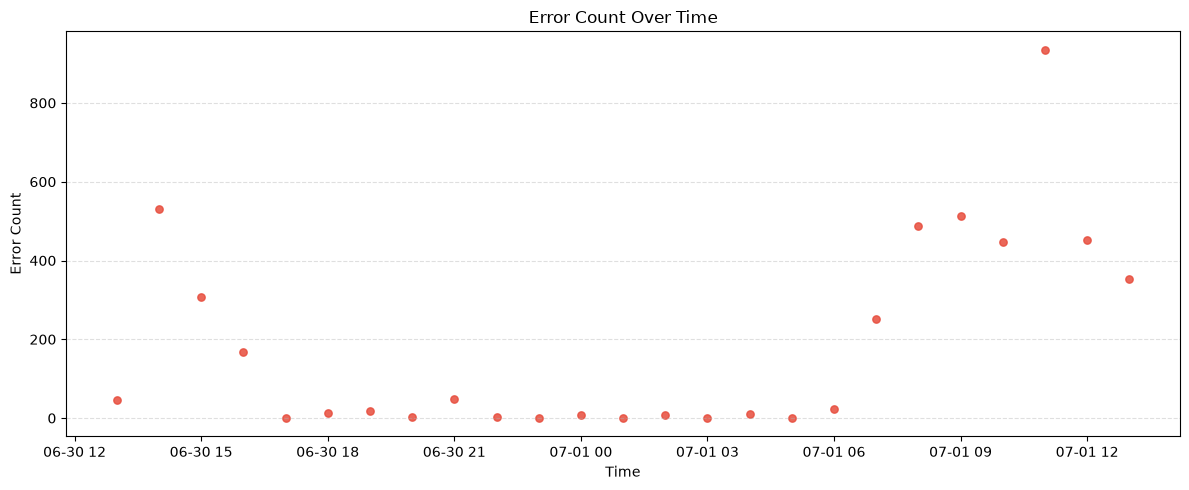

In [6]:
plt.figure(figsize=(12, 5))
plt.scatter(
    error_counts_over_time["timestamp"],
    error_counts_over_time["error_count"],
    color="#e74c3c",
    s=28,
    alpha=0.85,
)
plt.title("Error Count Over Time")
plt.xlabel("Time")
plt.ylabel("Error Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()